<a href="https://colab.research.google.com/github/sujithaindrakanti-sketch/SCT_DS_2/blob/main/task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Dataset - Data Cleaning and Exploratory Data Analysis

## Objective

The goal of this project is to clean the Titanic dataset and perform Exploratory Data Analysis (EDA) to understand relationships between passenger characteristics and survival.

The analysis focuses on identifying patterns and trends based on variables such as:
- Gender
- Passenger class
- Age
- Fare
- Family size
- Embarkation point

The main question explored:

**"What factors influenced the survival of passengers on the Titanic?"**

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set_style("whitegrid")

In [2]:
# Load Titanic dataset

df = pd.read_csv("/content/train.csv")

# Display first 5 rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Understanding the Dataset

The dataset contains information about Titanic passengers.

Important columns:

- Survived: Survival status (0 = No, 1 = Yes)
- Pclass: Passenger class
- Sex: Gender of passenger
- Age: Passenger age
- SibSp: Number of siblings/spouse onboard
- Parch: Number of parents/children onboard
- Fare: Ticket price
- Embarked: Boarding location

In [4]:
# Dataset shape

df.shape

(891, 12)

In [5]:
# Information about columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# Statistical summary

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Data Cleaning

Before analysis, missing values and unnecessary columns must be handled.

In [7]:
# Check missing values

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Handling Missing Values

Observations:

- Age contains missing values.
- Cabin has many missing values.
- Embarked contains few missing values.

Approach:

- Fill missing Age values using median.
- Fill missing Embarked values using mode.
- Remove Cabin because most values are missing.

In [3]:
# Fill missing Age values

df["Age"].fillna(df["Age"].median(), inplace=True)


# Fill Embarked missing values

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)


# Drop Cabin column

df.drop("Cabin", axis=1, inplace=True)


# Verify missing values

df.isnull().sum()

/tmp/ipykernel_7139/3326129087.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_7139/3326129087.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Feature Engineering

Creating new variables can help discover hidden patterns.

In [4]:
# Create family size feature

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1


df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


# Exploratory Data Analysis (EDA)

EDA helps us discover relationships between variables and survival.

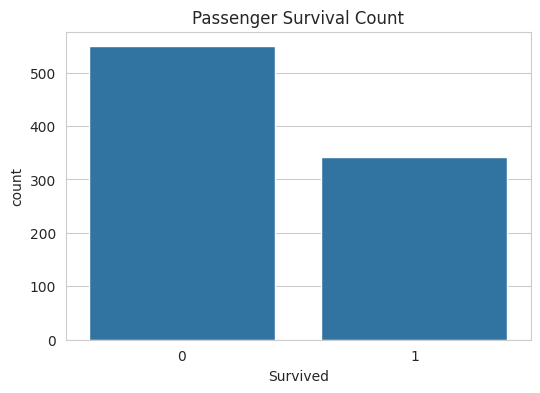

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(x="Survived", data=df)

plt.title("Passenger Survival Count")

plt.show()

### Insight:

The number of passengers who did not survive is higher than those who survived.

Only a smaller proportion of passengers survived the Titanic disaster, showing the severity of the event.

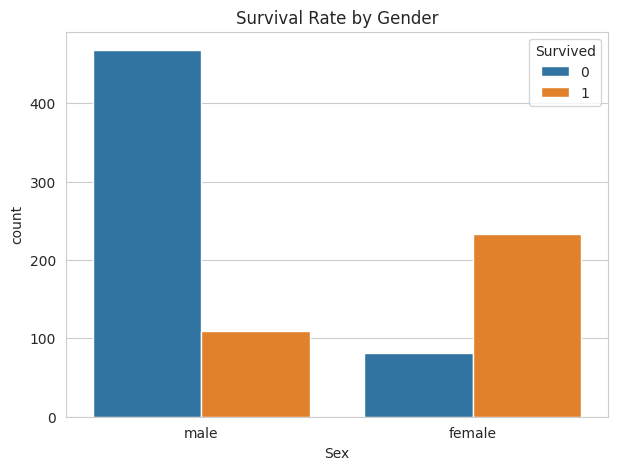

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)

plt.title("Survival Rate by Gender")

plt.show()

### Insight:

Female passengers had a much higher survival rate compared to male passengers.

This indicates that gender played an important role in survival, likely due to the evacuation priority given to women and children.

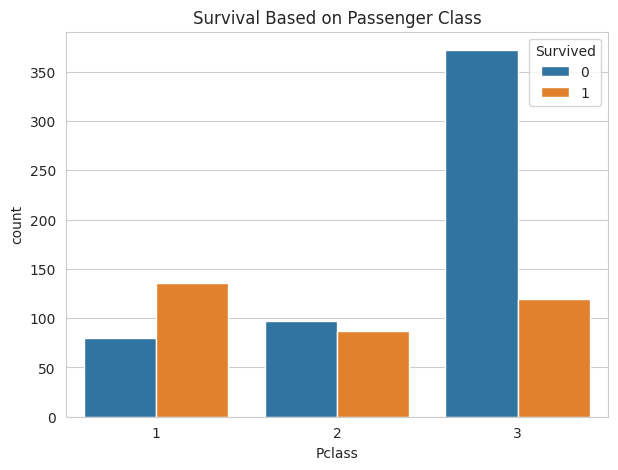

In [3]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Pclass",
    hue="Survived",
    data=df
)

plt.title("Survival Based on Passenger Class")

plt.show()

### Insight:

Passengers in first class had better survival chances compared to second and third class.

This suggests that socioeconomic status influenced access to lifeboats and survival opportunities.

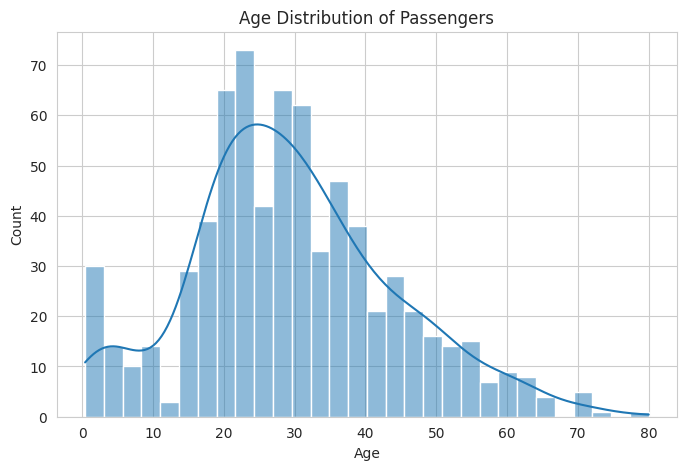

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Age"],
    bins=30,
    kde=True
)

plt.title("Age Distribution of Passengers")

plt.show()

### Insight:

Most passengers were young adults.

The dataset contains fewer elderly passengers compared to younger age groups.

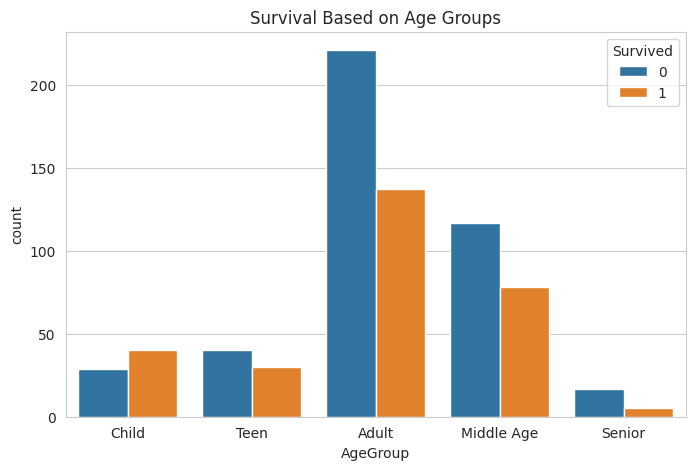

In [5]:
# Create age groups

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0,12,18,35,60,100],
    labels=[
        "Child",
        "Teen",
        "Adult",
        "Middle Age",
        "Senior"
    ]
)


plt.figure(figsize=(8,5))

sns.countplot(
    x="AgeGroup",
    hue="Survived",
    data=df
)

plt.title("Survival Based on Age Groups")

plt.show()

### Insight:

Children had relatively better survival rates compared to adults.

Age was an important factor affecting survival probability.

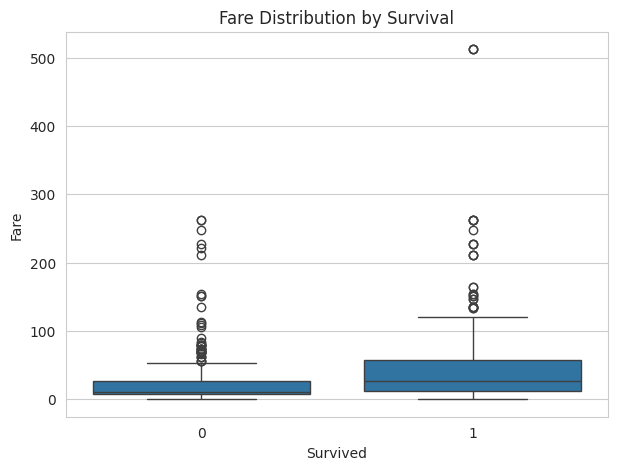

In [6]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Survived",
    y="Fare",
    data=df
)

plt.title("Fare Distribution by Survival")

plt.show()

### Insight:

Passengers who survived generally paid higher fares.

Higher ticket prices may represent higher class and better access to lifeboats.

In [5]:
# Create Family Size feature again

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Check it exists

df[["SibSp","Parch","FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


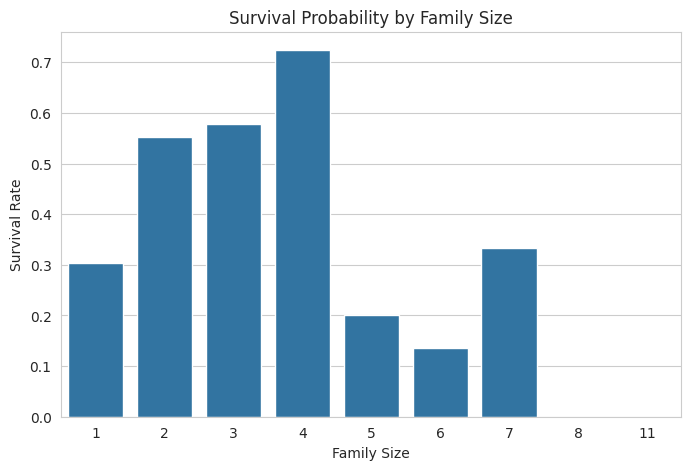

In [6]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="FamilySize",
    y="Survived",
    data=df,
    errorbar=None
)

plt.title("Survival Probability by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.show()

### Insight:

Passengers travelling with small families had better survival chances.

Very large families and passengers travelling alone showed lower survival rates.

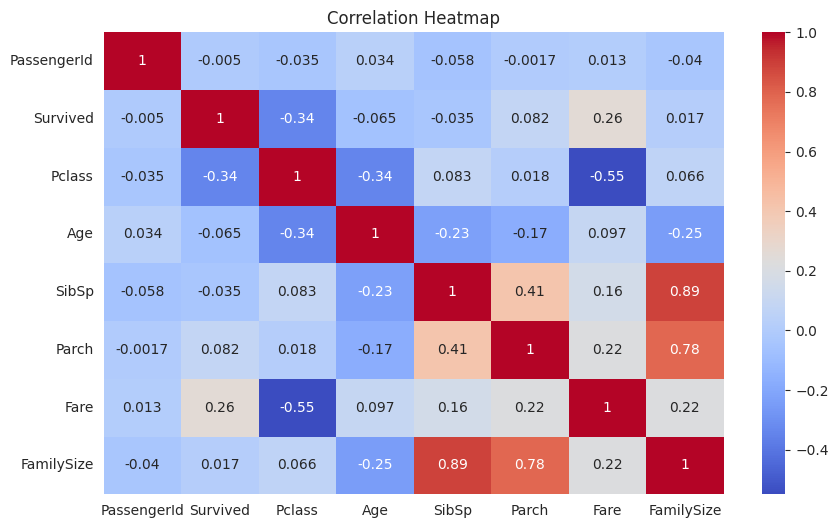

In [7]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Insight:

Important relationships:

- Passenger class has a relationship with survival.
- Fare is positively related to survival.
- Age has weaker influence compared to gender and class.

The analysis shows that survival depended mainly on social and demographic factors.

# Final Conclusion

From the exploratory analysis, the major factors affecting survival were:

1. Gender:
   - Females had much higher survival rates than males.

2. Passenger Class:
   - First-class passengers had greater chances of survival.

3. Fare:
   - Higher ticket fares were associated with increased survival.

4. Age:
   - Children had better survival chances.

5. Family Size:
   - Small families had better outcomes than very large groups.

Overall, survival on the Titanic was influenced by a combination of demographic and socioeconomic factors.